**BIT 3484 Spring 2026**

# Capstone Project III - Kickstarter Crowd Funding Analysis

### Group #: 6
### Members: Cooper Ritz, Tommy Devens, Grace Gavlinski


**Project Topic:** Crowdfunding Analytics / Kickstarter Project Success

**Goal:** Use data analysis and machine learning models to predict whether a Kickstarter campaign will be successfully funded and identify business recommendations for campaign creators.


## 1. Introduction

### Business Problem

Kickstarter and other crowdfunding platforms help creators raise money for projects, but many campaigns fail to reach their funding goals. For creators, understanding what factors increase the chance of success can help them set better goals, choose better campaign strategies, and improve their chances of receiving funding.

### Research Questions

1. What campaign and creator characteristics most strongly predict funding success?
2. Is there an optimal funding goal — do campaigns asking for too much or too little fail more often?
3. What actionable advice can we offer a creator launching a new campaign?

### Analysis Goals

The goal of this project is to build classification models that predict whether a Kickstarter campaign will succeed or fail. We will compare at least two models and use the results to make business recommendations for creators launching new campaigns. By doing this, we create value for creators to achieve success and launch products

## Setup ##

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, roc_curve, roc_auc_score)
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load and Explore the Data

In [7]:
df = pd.read_csv("ks-projects-201801.csv")
df.head()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


In [8]:
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns}")

Shape: (378661, 15)

Columns: Index(['ID', 'name', 'category', 'main_category', 'currency', 'deadline',
       'goal', 'launched', 'pledged', 'state', 'backers', 'country',
       'usd pledged', 'usd_pledged_real', 'usd_goal_real'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  object 
 2   category          378661 non-null  object 
 3   main_category     378661 non-null  object 
 4   currency          378661 non-null  object 
 5   deadline          378661 non-null  object 
 6   goal              378661 non-null  float64
 7   launched          378661 non-null  object 
 8   pledged           378661 non-null  float64
 9   state             378661 non-null  object 
 10  backers           378661 non-null  int64  
 11  country           378661 non-null  object 
 12  usd pledged       374864 non-null  float64
 13  usd_pledged_real  378661 non-null  float64
 14  usd_goal_real     378661 non-null  float64
dtypes: float64(5), int64(2), object(8)
memory usage: 43.3+ MB


In [10]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
ID                     0
name                   4
category               0
main_category          0
currency               0
deadline               0
goal                   0
launched               0
pledged                0
state                  0
backers                0
country                0
usd pledged         3797
usd_pledged_real       0
usd_goal_real          0
dtype: int64


In [11]:
df = df[df["state"].isin(["successful", "failed"])]

df["success"] = df["state"].map({"successful": 1, "failed": 0})

print(f"Dataset after filtering: {df.shape}")
print(f"\nSuccess rate: {df['success'].mean():.1%}")
print(df['state'].value_counts())

Dataset after filtering: (331675, 16)

Success rate: 40.4%
state
failed        197719
successful    133956
Name: count, dtype: int64


## Interpretation:
The overall success rate is 40.4%. Meaning that for every 10 campaigns on Kickstarter, only 4 in this dataset were successfully funded. Since the number of failed campaigns is higher than the number of successful campaigns, this shows that campaign success is not guaranteed and that failure is more common. This supports the purpose of this project because creators could benefit from understanding which factors make a campaign more likely to succeed.

In [13]:
pd.set_option("display.float_format", "{:,.2f}".format)
num_cols = ['goal', 'backers', 'usd_pledged_real', 'usd_goal_real']
df[num_cols].describe().round(2)

,goal,backers,usd_pledged_real,usd_goal_real
count,"331,675.00","331,675.00","331,675.00","331,675.00"
mean,"44,251.57",116.38,"9,943.46","41,510.00"
std,"1,117,916.70",965.43,"96,732.93","1,108,929.66"
min,0.01,0.00,0.00,0.01
25%,"2,000.00",2.00,50.00,"2,000.00"
50%,"5,000.00",15.00,788.00,"5,000.00"
75%,"15,000.00",63.00,"4,608.00","15,000.00"
max,"100,000,000.00","219,382.00","20,338,986.27","166,361,390.71"


The summary statistics show that Kickstarter campaigns vary greatly in size and funding performance. Out of 331,370 total campaigns, the average goal in USD was $41,150, but the median was only 5,000. This shows that a small number of campaigns that had huge goals are skewing the averages much higher. These patterns continue, looking at the other statistics, with pledged amounts and backers, where most campaigns receive relatively little support, but a few very successful campaigns raise very large amounts of money.

## 3. Feature Engineering

This section creates new variables that can help explain what leads to Kickstarter success.

features:

- Campaign duration
- Launch month
- Launch year
- Goal amount

In [16]:
df["launched"] = pd.to_datetime(df["launched"], errors="coerce")
df["deadline"] = pd.to_datetime(df["deadline"], errors="coerce")

df["campaign_days"] = (df["deadline"] - df["launched"]).dt.days

df["launch_month"] = df["launched"].dt.month
df["launch_year"] = df["launched"].dt.year

df['log_goal'] = np.log1p(df['usd_goal_real'])

df[["launched", "deadline", "campaign_days", "launch_month", "launch_year"]].head()


,launched,deadline,campaign_days,launch_month,launch_year
0,2015-08-11 12:12:28,2015-10-09,58,8,2015
1,2017-09-02 04:43:57,2017-11-01,59,9,2017
2,2013-01-12 00:20:50,2013-02-26,44,1,2013
3,2012-03-17 03:24:11,2012-04-16,29,3,2012
5,2016-02-26 13:38:27,2016-04-01,34,2,2016


## Interpretation:
The date columns were converted into a datetime format so they could be used to create new variables for analysis. From the launch and deadline dates, we created the campaign_days variable, which measures how long each Kickstarter campaign lasted. We also created launch_month and launch_year to track when the campaign started. These variables help identify whether campaign timing affects the chance of success.

We also created log_goal from usd_goal_real. This is important because the goal totals are highly skewed, with a few campaigns having extremely large goals. Taking the log of the goal amount reduces the impact of extreme values and makes the variable easier for the models to use. Overall, these new features give the models more useful information than the original raw data columns alone.

In [18]:
df = df.dropna()
df = df[df["campaign_days"] > 0]

print("Duration stats:")
print(df['campaign_days'].describe().round(1))
print(df.shape)

Duration stats:
count   331,370.00
mean         33.00
std          12.70
min           1.00
25%          29.00
50%          29.00
75%          35.00
max          91.00
Name: campaign_days, dtype: float64
(331370, 20)


## Interpretation
From the campaign_days, we see that the average campaign length is 33 days, but the median and 25% percentile are both 29 days. Using these numbers, we can likely conclude that the majority of campaigns are set to be open for 30 days. To clean the data, we also dropped missing values and campaigns that didn't run for a day. 

## 4. Exploratory Data Analysis

Use visuals to understand patterns in the data before modeling.


### Overall Success Rate

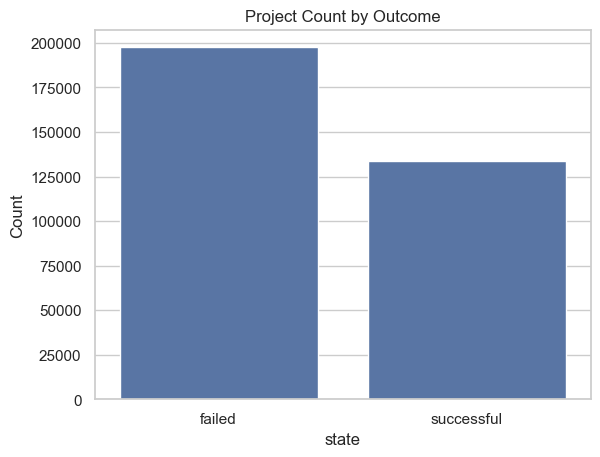

Success rate: 40.4%


In [22]:
success_counts = df['state'].value_counts()
sns.barplot(x = success_counts.index, y = success_counts.values)
plt.title('Project Count by Outcome')
plt.ylabel('Count')
plt.show()

print(f"Success rate: {df['success'].mean():.1%}")

### Success Rate by Category

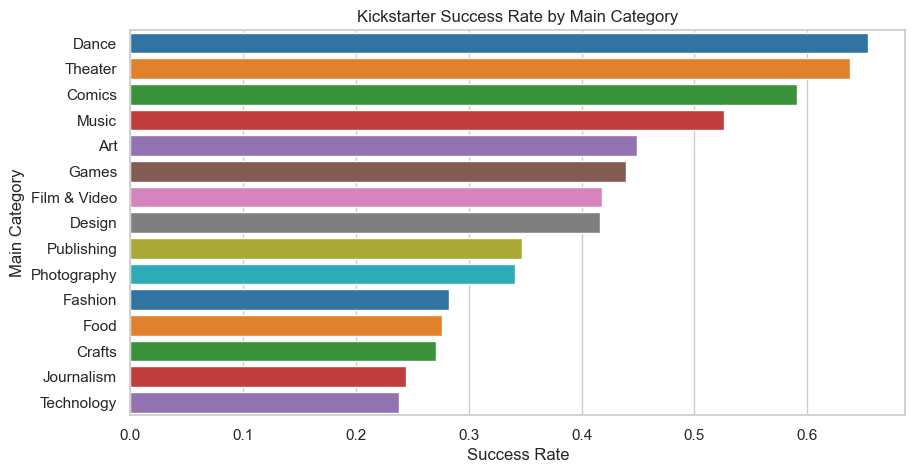

In [24]:
category_success = df.groupby("main_category")["success"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=category_success.values, y=category_success.index, hue = category_success.index, palette = 'tab10')
plt.title("Kickstarter Success Rate by Main Category")
plt.ylabel("Main Category")
plt.xlabel("Success Rate")
plt.show()


## Interpretation
From this bar chart, we can see the top categories and their success rates. Looking at this, we see that Dance and Theater are above 60% success rate, with comics and music not far behind, being over 50%. For the lowest success rate categories, Technology, Journalism, Crafts, and Food lead the way. This suggests that the type of project plays an important role in whether a Kickstarter campaign succeeds. Creative and performance categories may have stronger communities that support artists and creators, which could help campaigns reach their funding goals. This means people who are starting a campaign should compare their project to similar campaigns in their category before setting a goal and launching the campaign.

### Success Rate Based on the Funding Goal

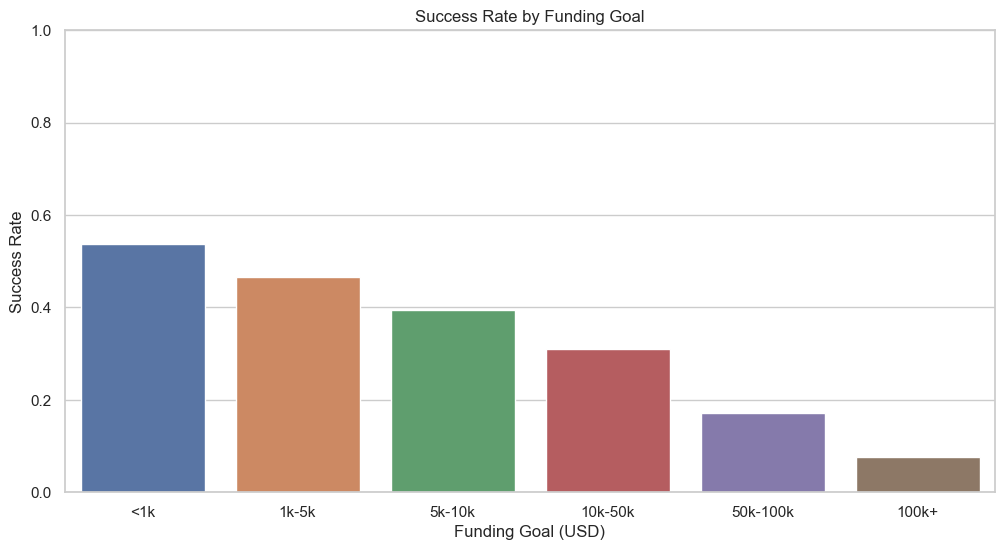

In [27]:
df['goal_bucket'] = pd.cut(df['usd_goal_real'], bins = [0, 1000, 5000, 10000, 50000, 100000, df['usd_goal_real'].max()],
                            labels = ['<1k', '1k-5k', '5k-10k', '10k-50k', '50k-100k', '100k+'])

goal_success = df.groupby('goal_bucket', observed = False)['success'].mean()

plt.figure(figsize = (12, 6))
sns.barplot(x = goal_success.index, y = goal_success.values, hue = goal_success.index)
plt.title('Success Rate by Funding Goal')
plt.xlabel('Funding Goal (USD)')
plt.ylabel('Success Rate')
plt.ylim(0,1)
plt.show()

## Interpretation:
As shown in this figure, success rates decline steadily as funding goals increase. Campaigns requesting under 1,000 dollars succeed at around 55%, while those requesting over 100,000 succeed only about 8% of the time. The sharpest drop occurs above 50,000, where success rates fall below 17%. This directly answers Research Question 2: There is no single optimal goal, but campaigns with goals below $10,000 consistently outperform those with larger goals. Creators should set the smallest realistic goal to maximize their chances of success.

### Correlation Heatmap 

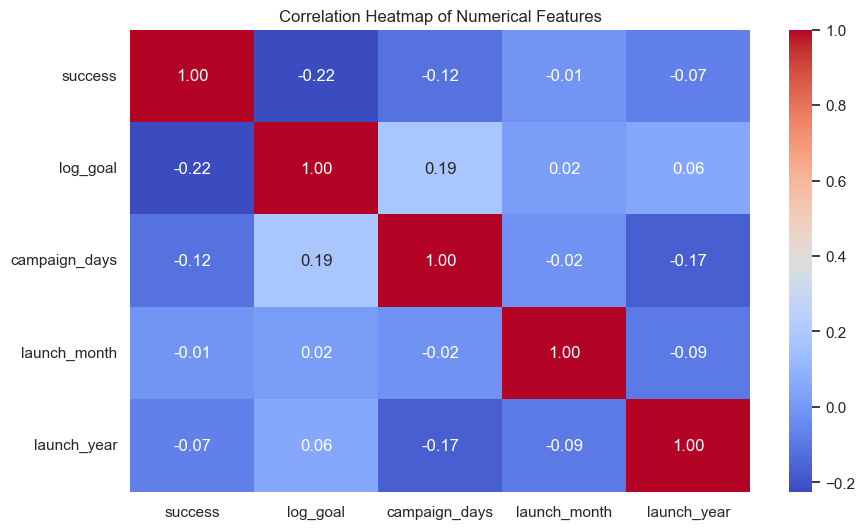

In [30]:
num_cols = ['success', 'log_goal', 'campaign_days', 'launch_month', 'launch_year']
plt.figure(figsize = (10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Interpretation
log_goal has the strongest correlation with success at -0.22, confirming that higher funding goals are associated with lower success rates. For campaign_days, it shows a weak and negative correlation of -0.12, suggesting longer campaigns are slightly less likely to succeed, but not as big an effect. launch_month and launch_year have near zero correlations with success at -0.01 and -0.07, meaning timing of a campaign alone has little linear relationship with the final outcome.

### Success VS. Failed Campaigns Based on the Log Goal

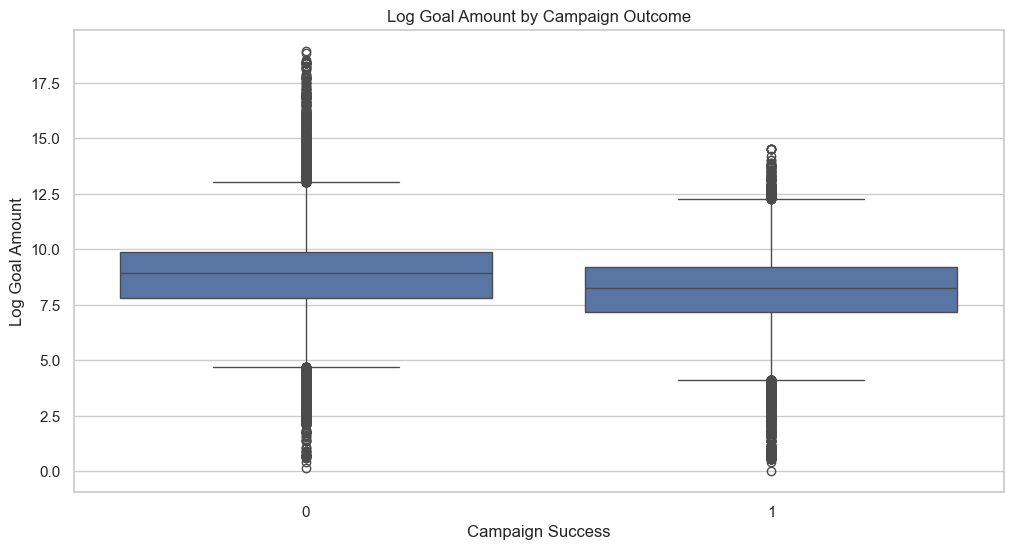

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(data = df, x = "success", y = "log_goal")
plt.title("Log Goal Amount by Campaign Outcome")
plt.xlabel("Campaign Success")
plt.ylabel("Log Goal Amount")
plt.show()


## Interpretation:
The boxplot compares the logarithmic goal amount for failed and successful Kickstarter campaigns. The failed campaigns have a slightly higher median log goal than the successful campaigns, meaning failed campaigns generally asked for more money. Successful campaigns tend to have lower funding goals, which supports the idea that setting a more realistic goal can improve the chance of success. There are also many outliers in both groups, showing that some campaigns had extremely low or extremely high funding goals. Overall, this graph supports the negative relationship between goal size and campaign success.

### Success Rate by Campaign Duration

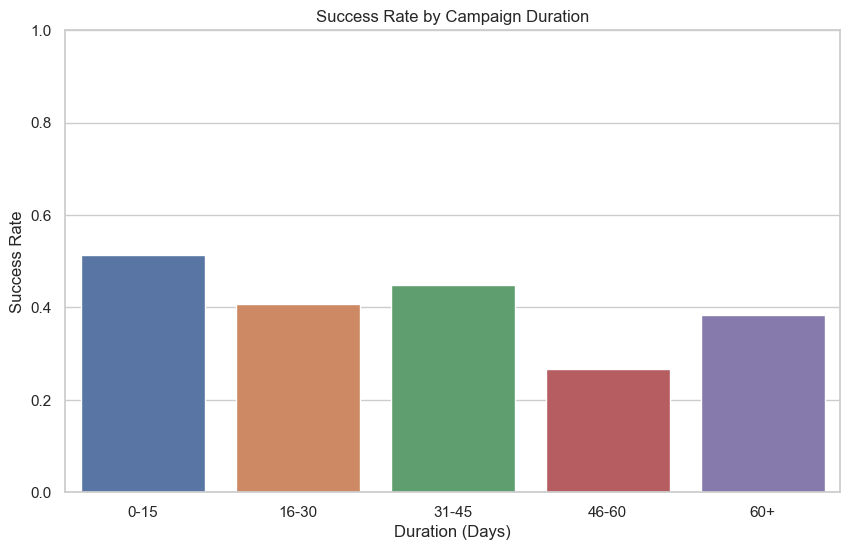

In [36]:
df['duration_bucket'] = pd.cut(df['campaign_days'], bins=[0, 15, 30, 45, 60, df['campaign_days'].max()],
                               labels=['0-15', '16-30', '31-45', '46-60', '60+'])
duration = df.groupby('duration_bucket', observed = False)['success'].mean()

plt.figure(figsize = (10, 6))
sns.barplot(x = duration.index, y = duration.values, hue = duration.index)
plt.title('Success Rate by Campaign Duration')
plt.xlabel('Duration (Days)')
plt.ylabel('Success Rate')
plt.ylim(0, 1.0)
plt.show()

## Interpretation:
This graph shows the average Kickstarter success rate for campaigns based on how many days they lasted. The highest success rates appear around shorter to medium campaign lengths, especially between about 10 and 30 days. Campaigns in this range often have success rates above 50%, well above the overall average of 40.4%. Success drops to around 40% for 16-30 day campaigns, while it goes back up for the 31-45 day bucket at about 45%. It then falls sharply for 46-60 day campaigns before partially recovering for campaigns over 60 days. The 46-60 day bucket stands out as the clear worst performing group. Overall, the data suggests that shorter, more focused campaigns tend to outperform longer ones.

### EDA Summary

* Campaigns with lower funding goals have significantly higher success rates, with campaigns under $1k succeeding at 54% compared to only 8% for campaigns over 100k.

* There is no single optimal funding goal, but campaigns under 10k consistently outperform larger ones. Success rates drop sharply above $50,000, falling from 39% to below 17%.
  
* Category is a strong predictor of success: Dance (65%) and Theater (63%) outperform Technology (24%) and Journalism (25%) by a wide margin.

  
* Shorter campaigns, 0-15 days, succeed at the highest rate, about 51% of the time, while campaigns in the 46-60 day range perform the worst at around 27%.

  
* Numerical features show a weak correlation with success, with log_goal being the strongest at -0.22. This likely suggests that categorical variables, such as category, carry significantly more predictive weight.


## 5. Prepare Data for Modeling

Before modeling, we need to choose predictor variables and encode categorical variables.


In [40]:
df.columns.tolist()

['ID',
 'name',
 'category',
 'main_category',
 'currency',
 'deadline',
 'goal',
 'launched',
 'pledged',
 'state',
 'backers',
 'country',
 'usd pledged',
 'usd_pledged_real',
 'usd_goal_real',
 'success',
 'campaign_days',
 'launch_month',
 'launch_year',
 'log_goal',
 'goal_bucket',
 'duration_bucket']

In [41]:
drop_cols = ['ID', 'name', 'state', 'goal', 'deadline', 'launched',
             'pledged', 'usd_pledged_real', 'backers', 'currency',
             'usd pledged', 'category', 'usd_goal_real',
             'goal_bucket', 'duration_bucket']

model_df = df.drop(columns=drop_cols, errors='ignore')
print(f"Remaining columns: {list(model_df.columns)}")

print(model_df.head())

Remaining columns: ['main_category', 'country', 'success', 'campaign_days', 'launch_month', 'launch_year', 'log_goal']
  main_category country  success  campaign_days  launch_month  launch_year  \
0    Publishing      GB        0             58             8         2015   
1  Film & Video      US        0             59             9         2017   
2  Film & Video      US        0             44             1         2013   
3         Music      US        0             29             3         2012   
5          Food      US        1             34             2         2016   

   log_goal  
0      7.34  
1     10.31  
2     10.71  
3      8.52  
5     10.82  


## Drop Reasonings
ID: Just an ID for each campaign, does not impact the model or predictions

name: Doesn't impact the model

state: We are using success as the encoding instead of state, so we can drop the variable

goal: We are using log_goal as our goal target, as it takes all goals in USD and fixed the heavy positve outliers from skewing the data and model

deadline and launched: We are using the campaign_days, launch_month, and launch_year variables we created instead

pledged: This variable would give the models answers instead of data that can be used for predictions

usd_pledged_read: We dropped this too, because it would give the model the final numbers that would shape the model to output unrealistic outcomes

backers: Dropped because the number of backers is only known after the campaign begins and is too closely tied to whether the campaign succeeds.

currency: We already put all the values into USD, so we don't need the variable.

usd_pledged: We dropped this because it would cause data leakage for the model.

category: The main_category variable takes the role of the category variable used.

usd_goal_real: The created log_goal column takes the values from this variable and turns it into better input for the model.

goal_bucket and duration_bucket: Only used for creating visualizations, not used in the modeling.

In [43]:
model_df = pd.get_dummies(model_df, columns=['main_category', 'country'], drop_first=True)

print(f"Shape after encoding: {model_df.shape}")
model_df.head()

Shape after encoding: (331370, 40)


,success,campaign_days,launch_month,launch_year,log_goal,main_category_Comics,main_category_Crafts,main_category_Dance,main_category_Design,main_category_Fashion,...,country_IT,country_JP,country_LU,country_MX,country_NL,country_NO,country_NZ,country_SE,country_SG,country_US
0,0,58,8,2015,7.34,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,59,9,2017,10.31,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0,44,1,2013,10.71,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,29,3,2012,8.52,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,1,34,2,2016,10.82,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [44]:
X = model_df.drop(columns=['success'])
y = model_df['success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (231959, 39), Test: (99411, 39)


## 6. Model 1: Logistic Regression

Logistic regression is useful because it predicts the probability of campaign success and helps explain which variables increase or decrease the likelihood of success.


In [46]:
log_model = LogisticRegression(solver = 'liblinear')

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

log_pred[:5]

array([0, 1, 0, 0, 1], dtype=int64)

In [47]:
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

print("Logistic Regression Results")
print(f"Accuracy: {accuracy_score(y_test, log_pred):.3f}")
print(f"Precision: {precision_score(y_test, log_pred):.3f}")
print(f"Recall: {recall_score(y_test, log_pred):.3f}")

log_cm = confusion_matrix(y_test, log_pred)
log_specificity = log_cm[0, 0] / (log_cm[0, 0] + log_cm[0, 1])
print(f"Specificity: {log_specificity:.3f}")



Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.82      0.74     59327
           1       0.60      0.40      0.48     40084

    accuracy                           0.65     99411
   macro avg       0.63      0.61      0.61     99411
weighted avg       0.64      0.65      0.63     99411

Logistic Regression Results
Accuracy: 0.651
Precision: 0.601
Recall: 0.397
Specificity: 0.822


## Model Metrics
The logistic regression model achieves an overall accuracy of 65.1%, indicating that it correctly identifies approximately two-thirds of campaigns. For precision, when the model predicted a campaign to be successful, it was only correct 60% of the time. Looking at recall, we see that for successful campaigns, the model performed poorly, only identifying about 40% of the total successful campaigns. Overall, the model is much better at predicting which campaigns will fail than those that will succeed, as shown by our high specificity score of 82.2%

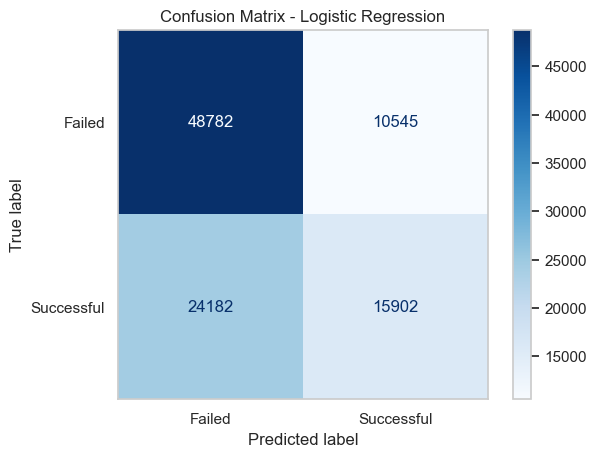

In [49]:
ConfusionMatrixDisplay(log_cm, display_labels=['Failed', 'Successful']).plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.grid(False)
plt.show()

## Interpretation
As shown in the confusion matrix, the model correctly identifies 48,782 failed campaigns and 15,902 successful campaigns. However, it incorrectly marks 24,182 successful campaigns as failures, and 10,545 failed campaigns as successes. The high false negative count aligns with the low recall score of our model, suggesting that the model likely struggles the most with correctly identifying successful campaigns.

## 7. Model 2: Random Forest

Random forest improves predictive accuracy by combining many decision trees. This model is useful for comparing feature importance.


In [52]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print(rf_pred[:5])

[0 0 0 0 0]


In [53]:
print("Classification Report:")
print(classification_report(y_test, rf_pred))

print("Random Forest Results")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print(f"Precision: {precision_score(y_test, rf_pred):.3f}")
print(f"Recall: {recall_score(y_test, rf_pred):.3f}")

rf_cm = confusion_matrix(y_test, rf_pred)
rf_specificity = rf_cm[0, 0] / (rf_cm[0, 0] + rf_cm[0, 1])
print(f"Specificity: {rf_specificity:.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.70     59327
           1       0.55      0.49      0.52     40084

    accuracy                           0.63     99411
   macro avg       0.62      0.61      0.61     99411
weighted avg       0.63      0.63      0.63     99411

Random Forest Results
Accuracy: 0.634
Precision: 0.552
Recall: 0.494
Specificity: 0.729


## Interpretation
The Random Forest model achieved an accuracy of 63.4%, which is slightly lower then 65.1% of the Logistic Regression model. For precision, it achieved a score of 0.552, meaning when the model predicts success, it is correct about 55% of the time. Recall did improve compared to Logistic Regression, from a 40% to a 49%, meaning nearly 50% of the total successful campaigns were correctly identified. Specificity drops to 0.729, confirming the Random Forest trades some ability to identify failures in exchange for better detection of successes.

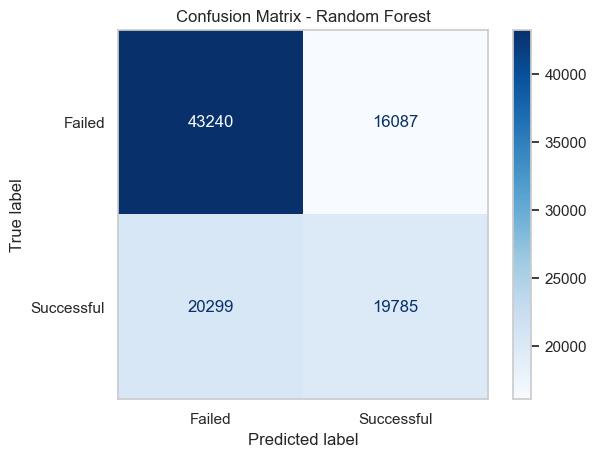

In [55]:
rf_disp = ConfusionMatrixDisplay(confusion_matrix = rf_cm, display_labels = ['Failed', 'Successful'])
#Values were showing up in scientific notation
rf_disp.plot(cmap= 'Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.grid(False)
plt.show()

## Interpretation
The Random Forest model correctly identifies 43,240 failed campaigns and 19,785 successful campaigns. When compared to logistic regression, it catches 3,883 more successful campaigns, but at the cost of misclassifying 5,542 more failed campaigns as successes. This tradeoff reflects the higher recall but lower specificity of the model.

## 8. Compare Model Performance

This section will compare all 4 models to see which one is truly the best.


In [58]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

tree = DecisionTreeClassifier(random_state=42, max_depth = 7)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [59]:
log_prob = log_model.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
lda_prob = lda.predict_proba(X_test)[:, 1]
tree_prob = tree.predict_proba(X_test)[:, 1]

log_auc = roc_auc_score(y_test, log_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
lda_auc = roc_auc_score(y_test, lda_prob)
tree_auc = roc_auc_score(y_test, tree_prob)

print(f"Logistic Regression AUC Score: {log_auc:.4f}")
print(f"Random Forest AUC Score: {rf_auc:.4f}")
print(f"LDA AUC Score: {lda_auc:.4f}")
print(f"Decision Tree AUC Score: {tree_auc:.4f}")

Logistic Regression AUC Score: 0.6822
Random Forest AUC Score: 0.6665
LDA AUC Score: 0.6858
Decision Tree AUC Score: 0.6865


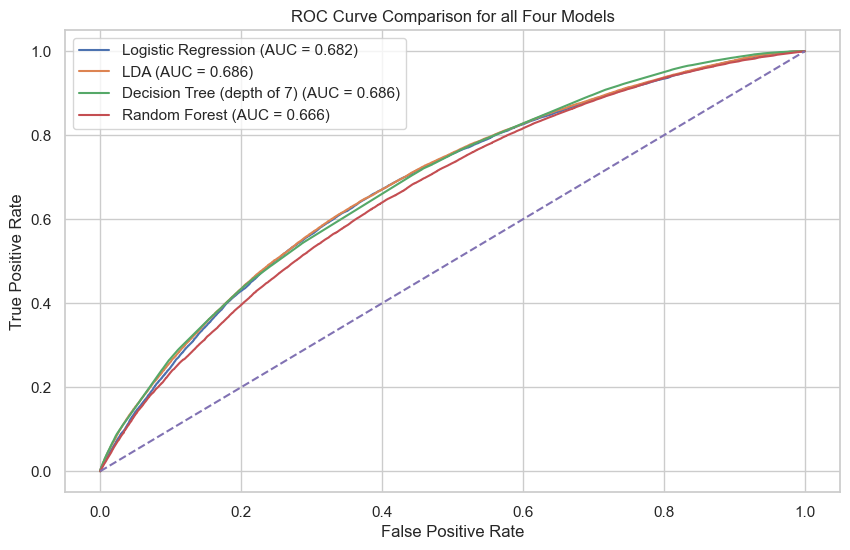

In [60]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
lda_fpr, lda_tpr, _ = roc_curve(y_test, lda_prob)
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)


plt.figure(figsize=(10,6))

plt.plot(log_fpr, log_tpr, label = f'Logistic Regression (AUC = {log_auc:.3f})')
plt.plot(lda_fpr, lda_tpr, label = f'LDA (AUC = {lda_auc:.3f})')
plt.plot(tree_fpr, tree_tpr, label = f'Decision Tree (depth of 7) (AUC = {tree_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label = f'Random Forest (AUC = {rf_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve Comparison for all Four Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Model Analysis
As shown in the ROC curve, LDA and Decision Tree perform best with an AUC of 0.686, followed closely by Logistic Regression at 0.682. Random Forest isn't far behind at 0.666. All four curves are very similar and are well above the random baseline, confirming that all models have meaningful predictions. The similarity between all 4 models suggests that the features and data themselves are the primary constraint on performance. If more helpful features were added to the dataset, model performance would likely increase across all 4.

In [62]:
lda_pred = lda.predict(X_test)
tree_pred = tree.predict(X_test)

model_compare = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest", "LDA", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lda_pred),
        accuracy_score(y_test, tree_pred)],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, lda_pred),
        precision_score(y_test, tree_pred)],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, lda_pred),
        recall_score(y_test, tree_pred)],
    "AUC": [
        log_auc,
        rf_auc,
        lda_auc,
        tree_auc]})

model_compare = model_compare.round(3)
model_compare

,Model,Accuracy,Precision,Recall,AUC
0,Logistic Regression,0.65,0.60,0.40,0.68
1,Random Forest,0.63,0.55,0.49,0.67
2,LDA,0.65,0.60,0.41,0.69
3,Decision Tree,0.65,0.60,0.42,0.69


## Model Comparison
Looking at the comparison table, all four models perform similarly, with accuracy ranging from 0.63 to 0.65 and AUC scores between 0.67 and 0.69. Logistic Regression, LDA, and Decision Tree all achieve the same accuracy of 65% and precision of 60%, suggesting the relationships in the data are largely linear and that there is not much of a difference between simple and complex models in terms of performance with this data. Random Forest has the lowest accuracy and AUC but the highest recall of 49%, meaning it identifies more successful campaigns at the cost of more false positives.

## 9. Feature Importance

                     Feature  Coefficient  Odds_Ratio
17     main_category_Theater         0.67        1.96
8      main_category_Fashion        -0.52        0.59
4       main_category_Comics         0.51        1.66
5       main_category_Crafts        -0.49        0.62
13       main_category_Music         0.48        1.62
10        main_category_Food        -0.47        0.63
16  main_category_Technology        -0.45        0.64
38                country_US         0.32        1.37
15  main_category_Publishing        -0.30        0.74
6        main_category_Dance         0.30        1.35
7       main_category_Design         0.29        1.34
11       main_category_Games         0.28        1.32
3                   log_goal        -0.27        0.76
26                country_GB         0.25        1.29
12  main_category_Journalism        -0.24        0.78


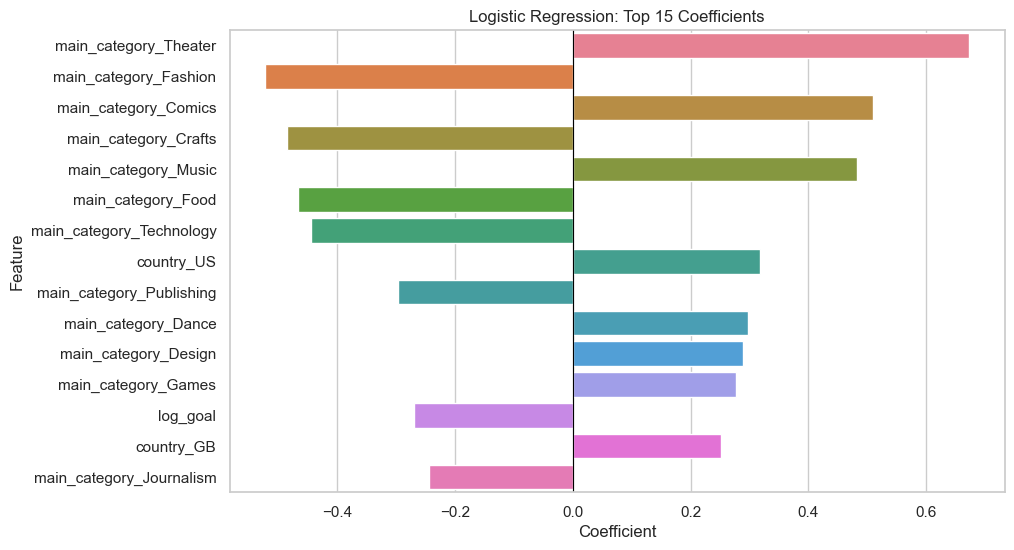

In [65]:
log_importance = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': log_model.coef_[0]})

log_importance['Odds_Ratio'] = np.exp(log_importance['Coefficient'])
log_importance['Abs_Coefficient'] = np.abs(log_importance['Coefficient'])
log_importance = log_importance.sort_values('Abs_Coefficient', ascending=False)

print(log_importance[['Feature', 'Coefficient', 'Odds_Ratio']].head(15))

plt.figure(figsize = (10, 6))
sns.barplot(data = log_importance.head(15), x = 'Coefficient', y= 'Feature', hue = 'Feature', legend = False)
plt.title('Logistic Regression: Top 15 Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

## Logistic Regression Feature Importance
The category of the campaign is the strongest predictor of success using the logistic regression model. Theater has the highest positive coefficient of 0.67 and an odds ratio of 1.96, meaning theater campaigns are nearly twice as likely to succeed compared to the baseline campaign. Comics and music campaigns also significantly increase the odds of success. Looking at the negative coefficients, fashion and crafts, scoring around -0.50, are the strongest predictors of failure, reducing the odds of success by roughly 40%. When looking at a numerical predictor, log_goal carries a negative coefficient and an odds ratio of 0.76, confirming our findings that higher funding goals reduce success odds even after controlling for category and country. Another success variable we see is country, as launching from the US or GB provides a modest advantage over other countries.

In [67]:
feature_importance = pd.DataFrame({"Feature": X_train.columns,"Importance": rf.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
3,log_goal,0.43
0,campaign_days,0.20
1,launch_month,0.18
2,launch_year,0.08
13,main_category_Music,0.01
16,main_category_Technology,0.01
17,main_category_Theater,0.01
15,main_category_Publishing,0.01
38,country_US,0.01
4,main_category_Comics,0.01


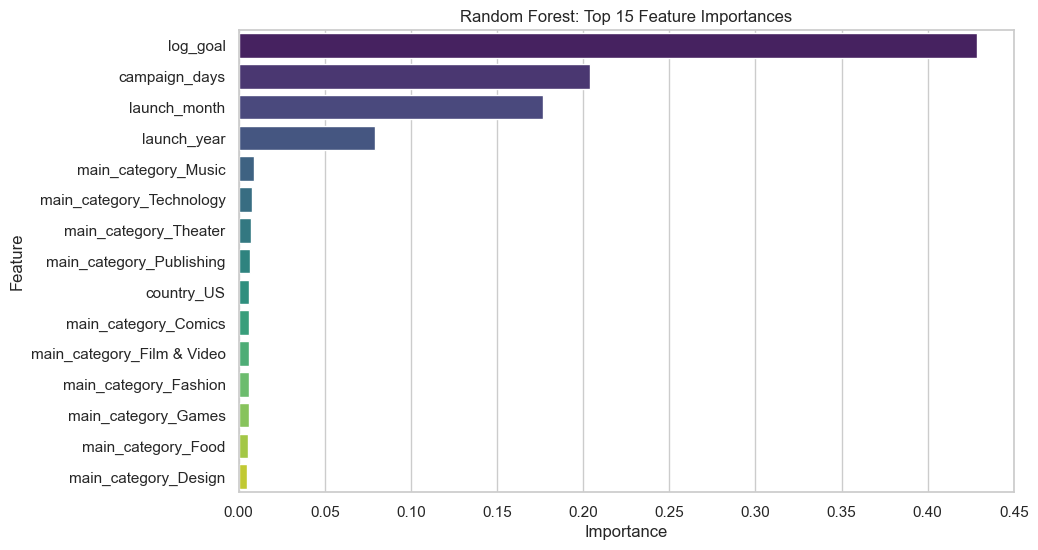

In [68]:
plt.figure(figsize = (10, 6))
sns.barplot(data = feature_importance.head(15), x = 'Importance', y = 'Feature', hue = 'Feature', palette = 'viridis', legend = False)
plt.title('Random Forest: Top 15 Feature Importances')
plt.xlim(0, 0.45)
plt.show()

## Random Forest Feature Importance
The table and figure above clearly show the dominance of log_goal over all other features. The four numerical features of log_goal, campaign_days, launch_month, and launch_year account for the vast majority of predictive power, with category variables each contributing only marginally on an individual basis. Moving to the category variables, Music and Technology appear most prominently, consistent with their considerable success and failure rates observed in our EDA findings. 

## Feature Importance Interpretation
Both models agree that the funding goal of a campaign is the primary predictor of success. However, they differ on what matters after; Random Forest says that campaign duration and timing are the second and third most important features, while Logistic Regression highlights category as the dominant predictor. This difference in what is important shows how each model works: Random Forest captures interaction effects between features, while Logistic Regression focuses on each variable's independent contribution to success. The most reliable conclusion is that goal size, campaign duration, and category all matter, and that creators should optimize all three rather than relying on any single factor.

# 10. Key Findings

**What makes a Kickstarter campaign succeed or fail?**

* Funding goal is the single strongest predictor of success. Campaigns with goals under $1,000 succeed at 54% while those above 100,000 dollars succeed at only 8%. Category is the strongest directional signal using the Logistic Regression model, with creative and performance-based campaigns, such as Theater, Dance, and Comic campaigns, being nearly twice as likely to succeed, while Fashion and Crafts reduce success odds by roughly 40%. Campaign duration also plays a role, with shorter campaigns, 0-15 days, succeeding at 51% compared to 27% for campaigns in the 46-60 day range.  Lastly, Launch month was identified as a moderately important predictor, suggesting timing interacts with other factors to influence success. 

**Is there an optimal funding goal – do projects that ask for too much or too little fail more
often?**

* There is no single optimal goal, but the data strongly favors keeping goals below $10,000. Success rates decline consistently as goals increase, with the sharpest drop occurring above 50,000 dollars, where success falls below 17%. Campaigns asking for under 5,000 dollars succeed at nearly 47%, making this the most favorable range. This shows that asking for too much money makes it much harder for a campaign to succeed. Our EDA findings and visuals also supported this finding because log_goal had a negative relationship with success. However, this does not mean every creator should set the lowest possible goal, as the goal still needs to be realistic enough to fund the creator's campaign. The main takeaway from the funding goal is that creators should avoid setting goals that are too ambitious compared to their expected audience and backer support. 

**What advice would we give a creator launching a new project to maximize their chance of funding?**

* The first piece of advice for creators starting a campaign is that they should focus first on setting a realistic funding goal. Since higher goals were connected with lower success rates, creators should try to estimate the minimum amount they need to complete the project and avoid asking for more than necessary at launch. Creators should also study successful campaigns in their same category because category performance differs a lot across Kickstarter, and the campaign also needs to fit the criteria for the category. A Theater or Music campaign may have different expectations than a Technology or Food campaign. Campaign duration should also be planned carefully. Our findings suggest that shorter campaigns perform better then longer, drawn-out campaigns. Creators should create a sense of urgency to get their campaign funded, without sacrificing too much time for the campaign to reach its goal. Overall, the best strategy is to set a reasonable goal, understand category-specific trends, and choose an effective campaign length. All of this shows a clear plan that will lead to a greater chance of success.

## 11. Managerial Recommendations

Based on your model results and feature importance, what specific success strategies would you recommend?

Our first recommendation for a creator is to set a realistic funding goal. Our analysis showed that campaigns with smaller goals were much more likely to succeed, while campaigns with very large goals had much lower success rates. Creators should try to calculate the minimum amount needed to complete the project and launch with that amount rather than asking for the highest possible number. For large projects, if possible, the campaign should be broken into phases. Use the first goal to fund the first milestone on Kickstarter and use that success to bring in additional investment or run a follow-up campaign to get the money needed to meet the following phases. This gives the campaign a better chance of reaching its initial goal while still allowing room for growth.

Our next recommendation is not to treat all Kickstarter categories the same. The results showed that creative and performance categories such as Dance, Theater, Comics, and Music had higher success rates, while Technology, Journalism, Crafts, Food, and Fashion had lower success rates. Before launching, creators should study successful and failed campaigns within their specific category. This can help them choose a better funding goal, campaign length, and strategy. For campaigns that also cross over multiple categories, it is best to put their campaign in the highest-performing category for the best chance of success. 

Our third recommendation is to run a shorter and more focused campaign. Campaigns lasting 0-15 days succeed at the highest rate of 51%, while those running 46-60 days succeed at just a 27% rate. We would recommend a range of 10 - 30 days, allowing campaigns to create urgency in potential backers while still giving enough time to reach funding goals.

Lastly, the biggest thing for a creator is to focus fully on what they can control in their campaign. While certain markets, such as the U.S. and Great Britain, have the highest success rates, not every creator has the ability to launch their campaign in these markets. However, creators can still market toward audiences in stronger markets when possible. Category and launch_month are also limited in what a creator can control. It would be great to be able to launch a product in any category or wait for a month that is best for launching, but it is just not possible for every creator, and they should focus mainly on what they can control in the funding goal and campaign duration.

## Final Visualizations
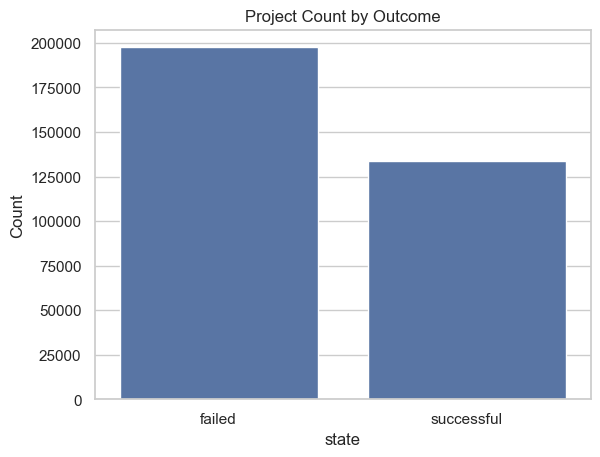

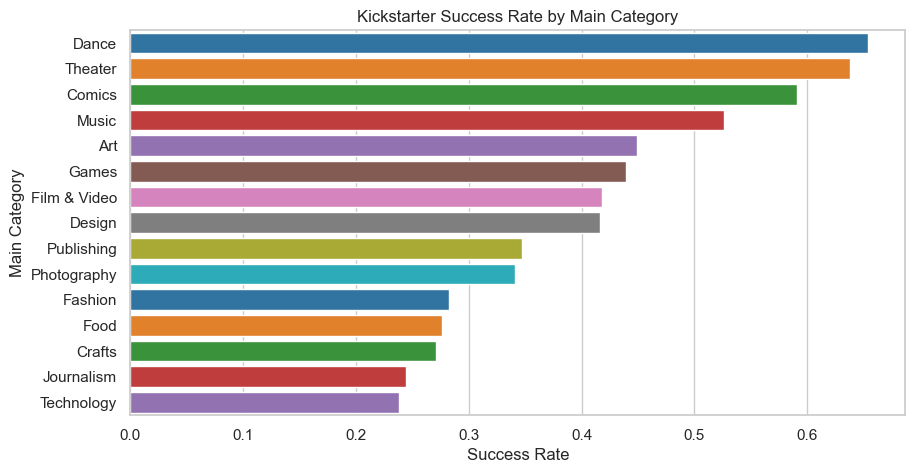

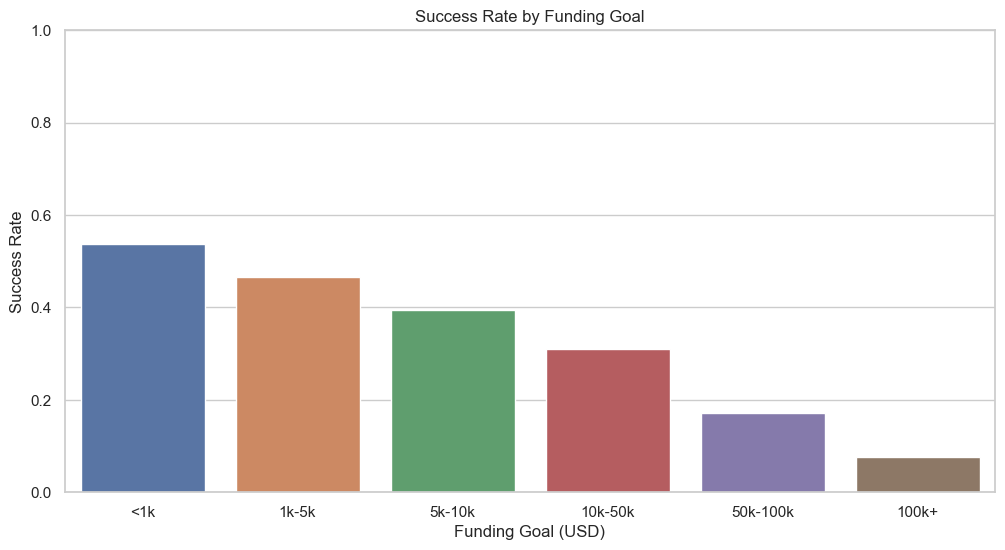

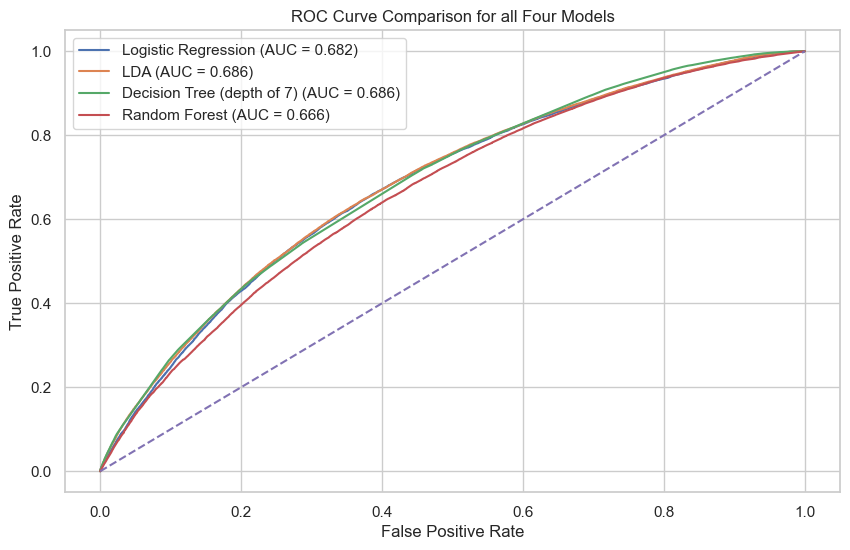

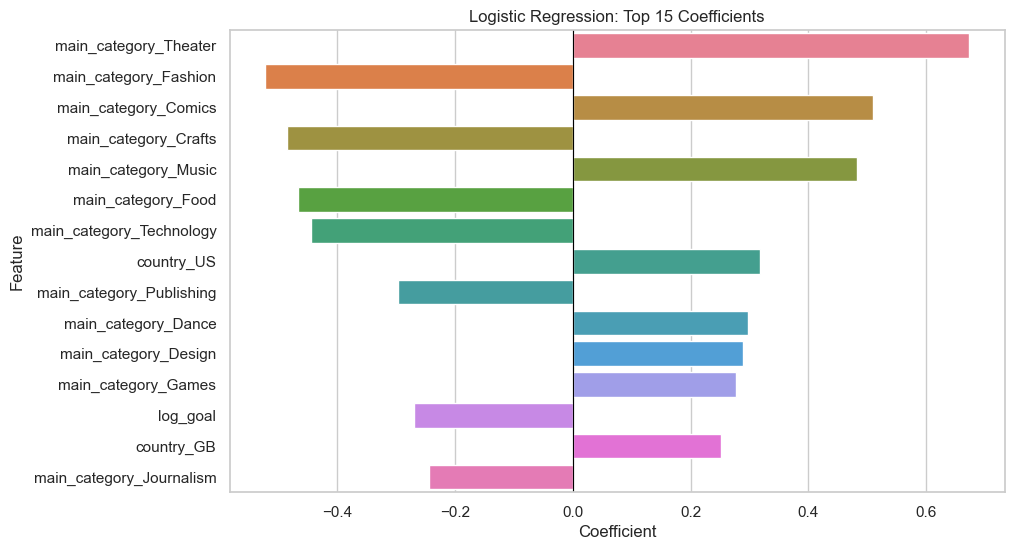

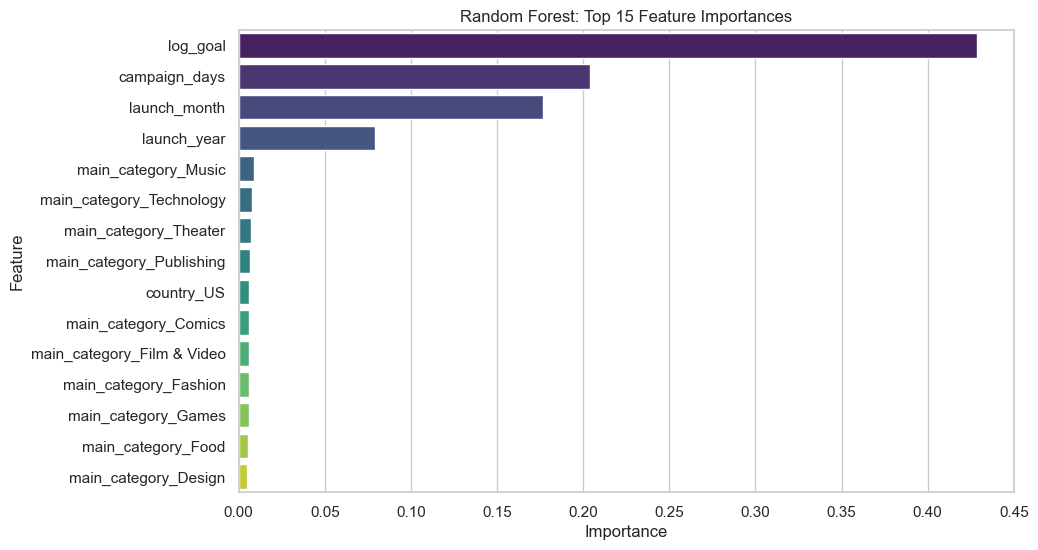

## Limitations

What are the limitations of this analysis?

One of the main limitations in this analysis is that we can only see the numbers and variables of the campaign and not the actual quality. Successful campaigns likely have momentum going into the campaign through social media, the creator's reputation, and an already existing audience to support the campaign. Creators who just launch a campaign without any prior buildup are unlikely to succeed even if they optimize the success predictors we found. Another limitation is that this dataset is a snapshot of 2018 Kickstarter campaigns and cannot account for current-day trends and users of Kickstarter. What might have worked in 2018 likely doesn't have the same impact 8 years later.

## Potential Extensions

What additional analysis could be done?
One potential extension is to add data on the creators themselves. First-time creators most likely will not achieve the same success rates as creators who have published multiple campaigns and have reached funding goals before. Established creators have a much larger audience and the ability to bring in many more backers to their campaigns.

Another potential extension is to analyze recent Kickstarter data, so that we can compare if success factors from this dataset are the same across multiple years. If trends at this point lead to certain categories or launch months being favored, this might not be true for campaigns launching in 2026.